In [185]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from datetime import datetime
from random import sample


In [186]:
# Load and train Dataset
Train_Beneficiarydata=pd.read_csv("../Data/Train_Beneficiarydata-1542865627584.csv")
Train_Inpatientdata= pd.read_csv("../Data/Train_Inpatientdata-1542865627584.csv")
Train_Outpatientdata= pd.read_csv("../Data/Train_Outpatientdata-1542865627584.csv")
Train = pd.read_csv("../Data/Train-1542865627584.csv")

# Load test dataset
Test_Beneficiarydata =pd.read_csv("../Data/Test_Beneficiarydata-1542969243754.csv")
Test_Inpatientdata =pd.read_csv("../Data/Test_Inpatientdata-1542969243754.csv")
Test_Outpatientdata =pd.read_csv("../Data/Test_Outpatientdata-1542969243754.csv")
Test= pd.read_csv("../Data/Test-1542969243754.csv")

In [187]:
Train.shape,Train_Beneficiarydata.shape,Train_Inpatientdata.shape,Train_Outpatientdata.shape,Train.shape

((5410, 2), (138556, 25), (40474, 30), (517737, 27), (5410, 2))

In [188]:
Test_Beneficiarydata.shape, Test_Inpatientdata.shape, Test_Outpatientdata.shape, Test.shape

((63968, 25), (9551, 30), (125841, 27), (1353, 1))

In [189]:
Train_Beneficiarydata.head(8)

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,...,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,...,1,1,1,2,1,1,36000,3204,60,70
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,...,2,2,2,2,2,2,0,0,30,50
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,...,2,2,1,2,2,2,0,0,90,40
3,BENE11004,1922-07-01,NaN,1,1,0,39,270,12,12,...,2,1,1,1,1,2,0,0,1810,760
4,BENE11005,1935-09-01,NaN,1,1,0,24,680,12,12,...,2,1,2,2,2,2,0,0,1790,1200
5,BENE11006,1976-09-01,NaN,2,1,0,23,810,12,12,...,2,2,2,2,2,2,0,0,500,0
6,BENE11007,1940-09-01,2009-12-01,1,2,0,45,610,12,12,...,2,1,2,1,1,2,0,0,1490,160
7,BENE11008,1934-02-01,NaN,2,1,0,15,140,12,12,...,2,1,2,2,2,2,0,0,30,0


In [190]:
Train_Beneficiarydata.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 138556 entries, 0 to 138555
Data columns (total 25 columns):
 #   Column                           Non-Null Count   Dtype
---  ------                           --------------   -----
 0   BeneID                           138556 non-null  str  
 1   DOB                              138556 non-null  str  
 2   DOD                              1421 non-null    str  
 3   Gender                           138556 non-null  int64
 4   Race                             138556 non-null  int64
 5   RenalDiseaseIndicator            138556 non-null  str  
 6   State                            138556 non-null  int64
 7   County                           138556 non-null  int64
 8   NoOfMonths_PartACov              138556 non-null  int64
 9   NoOfMonths_PartBCov              138556 non-null  int64
 10  ChronicCond_Alzheimer            138556 non-null  int64
 11  ChronicCond_Heartfailure         138556 non-null  int64
 12  ChronicCond_KidneyDisease        138556 n

In [191]:
Train_Beneficiarydata.isna().sum()

BeneID                                  0
DOB                                     0
DOD                                137135
Gender                                  0
Race                                    0
RenalDiseaseIndicator                   0
State                                   0
County                                  0
NoOfMonths_PartACov                     0
NoOfMonths_PartBCov                     0
ChronicCond_Alzheimer                   0
ChronicCond_Heartfailure                0
ChronicCond_KidneyDisease               0
ChronicCond_Cancer                      0
ChronicCond_ObstrPulmonary              0
ChronicCond_Depression                  0
ChronicCond_Diabetes                    0
ChronicCond_IschemicHeart               0
ChronicCond_Osteoporasis                0
ChronicCond_rheumatoidarthritis         0
ChronicCond_stroke                      0
IPAnnualReimbursementAmt                0
IPAnnualDeductibleAmt                   0
OPAnnualReimbursementAmt          

In [192]:
Test_Beneficiarydata.isna().sum()

BeneID                                 0
DOB                                    0
DOD                                63394
Gender                                 0
Race                                   0
RenalDiseaseIndicator                  0
State                                  0
County                                 0
NoOfMonths_PartACov                    0
NoOfMonths_PartBCov                    0
ChronicCond_Alzheimer                  0
ChronicCond_Heartfailure               0
ChronicCond_KidneyDisease              0
ChronicCond_Cancer                     0
ChronicCond_ObstrPulmonary             0
ChronicCond_Depression                 0
ChronicCond_Diabetes                   0
ChronicCond_IschemicHeart              0
ChronicCond_Osteoporasis               0
ChronicCond_rheumatoidarthritis        0
ChronicCond_stroke                     0
IPAnnualReimbursementAmt               0
IPAnnualDeductibleAmt                  0
OPAnnualReimbursementAmt               0
OPAnnualDeductib

In [193]:
Train_Beneficiarydata.columns

Index(['BeneID', 'DOB', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator',
       'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov',
       'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
       'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
       'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
       'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart',
       'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis',
       'ChronicCond_stroke', 'IPAnnualReimbursementAmt',
       'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt',
       'OPAnnualDeductibleAmt'],
      dtype='str')

In [194]:
#find the duplicates
Train_Beneficiarydata['BeneID'].duplicated().sum

<bound method Series.sum of 0         False
1         False
2         False
3         False
4         False
          ...  
138551    False
138552    False
138553    False
138554    False
138555    False
Name: BeneID, Length: 138556, dtype: bool>

In [195]:
#Test_Beneficiarydata['BeneID'].duplicated().sum

In [196]:
Train_Beneficiarydata['Gender'].value_counts()

Gender
2    79106
1    59450
Name: count, dtype: int64

In [197]:
#Test_Beneficiarydata['Gender'].value_counts()

In [ ]:
#1 = yes; 2 = no.then we replaced 2 with 0 
Train_Beneficiarydata['Gender']= Train_Beneficiarydata['Gender'].replace(2, 0)
Test_Beneficiarydata['Gender']=Train_Beneficiarydata['Gender'].replace(2, 0)
Train_Beneficiarydata['Gender'].value_counts()

Gender
0    79106
1    59450
Name: count, dtype: int64

In [199]:
Train_Beneficiarydata['RenalDiseaseIndicator'].value_counts()

RenalDiseaseIndicator
0    118978
Y     19578
Name: count, dtype: int64

In [200]:
Train_Beneficiarydata['RenalDiseaseIndicator'] =Train_Beneficiarydata['RenalDiseaseIndicator'].replace("Y", 1)
Test_Beneficiarydata['RenalDiseaseIndicator']=Test_Beneficiarydata['RenalDiseaseIndicator'].replace("Y", 1)
Train_Beneficiarydata['RenalDiseaseIndicator'].value_counts()

RenalDiseaseIndicator
0    118978
1     19578
Name: count, dtype: int64

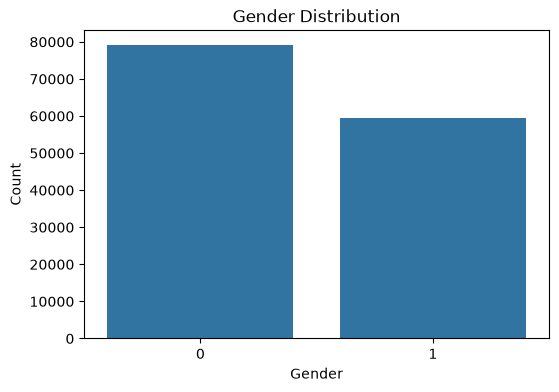

In [201]:
plt.figure(figsize=(6,4))
sns.countplot(data=Train_Beneficiarydata,x='Gender')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

In [202]:
Train_Beneficiarydata['Race'].value_counts()

Race
1    117057
2     13538
3      5059
5      2902
Name: count, dtype: int64

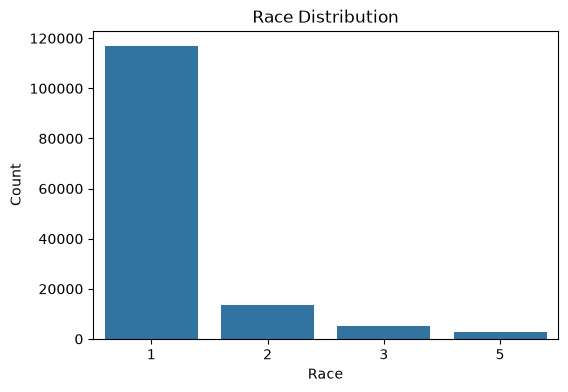

In [203]:
plt.figure(figsize=(6,4))
sns.countplot(data=Train_Beneficiarydata,x='Race')
plt.title('Race Distribution')
plt.xlabel('Race')


plt.ylabel('Count')
plt.show()

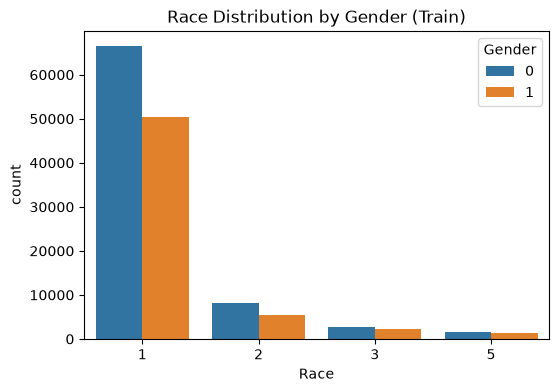

In [204]:
plt.figure(figsize=(6,4))
sns.countplot(x='Race', hue='Gender', data=Train_Beneficiarydata)
plt.title("Race Distribution by Gender (Train)")
plt.show()

In [ ]:
df_diseases = Train_Beneficiarydata.columns[10:21]
print(df_diseases)

#1 = yes; 2=no, then we replace 2 with 0
Train_Beneficiarydata[df_diseases]=Train_Beneficiarydata[df_diseases].replace(2, 0)
Test_Beneficiarydata[df_diseases]= Test_Beneficiarydata[df_diseases].replace(2, 0)
Train_Beneficiarydata.head(8)

Index(['ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
       'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
       'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
       'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart',
       'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis',
       'ChronicCond_stroke'],
      dtype='str')


,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,...,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,...,1,1,1,0,1,1,36000,3204,60,70
1,BENE11002,1936-09-01,NaN,0,1,0,39,280,12,12,...,0,0,0,0,0,0,0,0,30,50
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,...,0,0,1,0,0,0,0,0,90,40
3,BENE11004,1922-07-01,NaN,1,1,0,39,270,12,12,...,0,1,1,1,1,0,0,0,1810,760
4,BENE11005,1935-09-01,NaN,1,1,0,24,680,12,12,...,0,1,0,0,0,0,0,0,1790,1200
5,BENE11006,1976-09-01,NaN,0,1,0,23,810,12,12,...,0,0,0,0,0,0,0,0,500,0
6,BENE11007,1940-09-01,2009-12-01,1,2,0,45,610,12,12,...,0,1,0,1,1,0,0,0,1490,160
7,BENE11008,1934-02-01,NaN,0,1,0,15,140,12,12,...,0,1,0,0,0,0,0,0,30,0


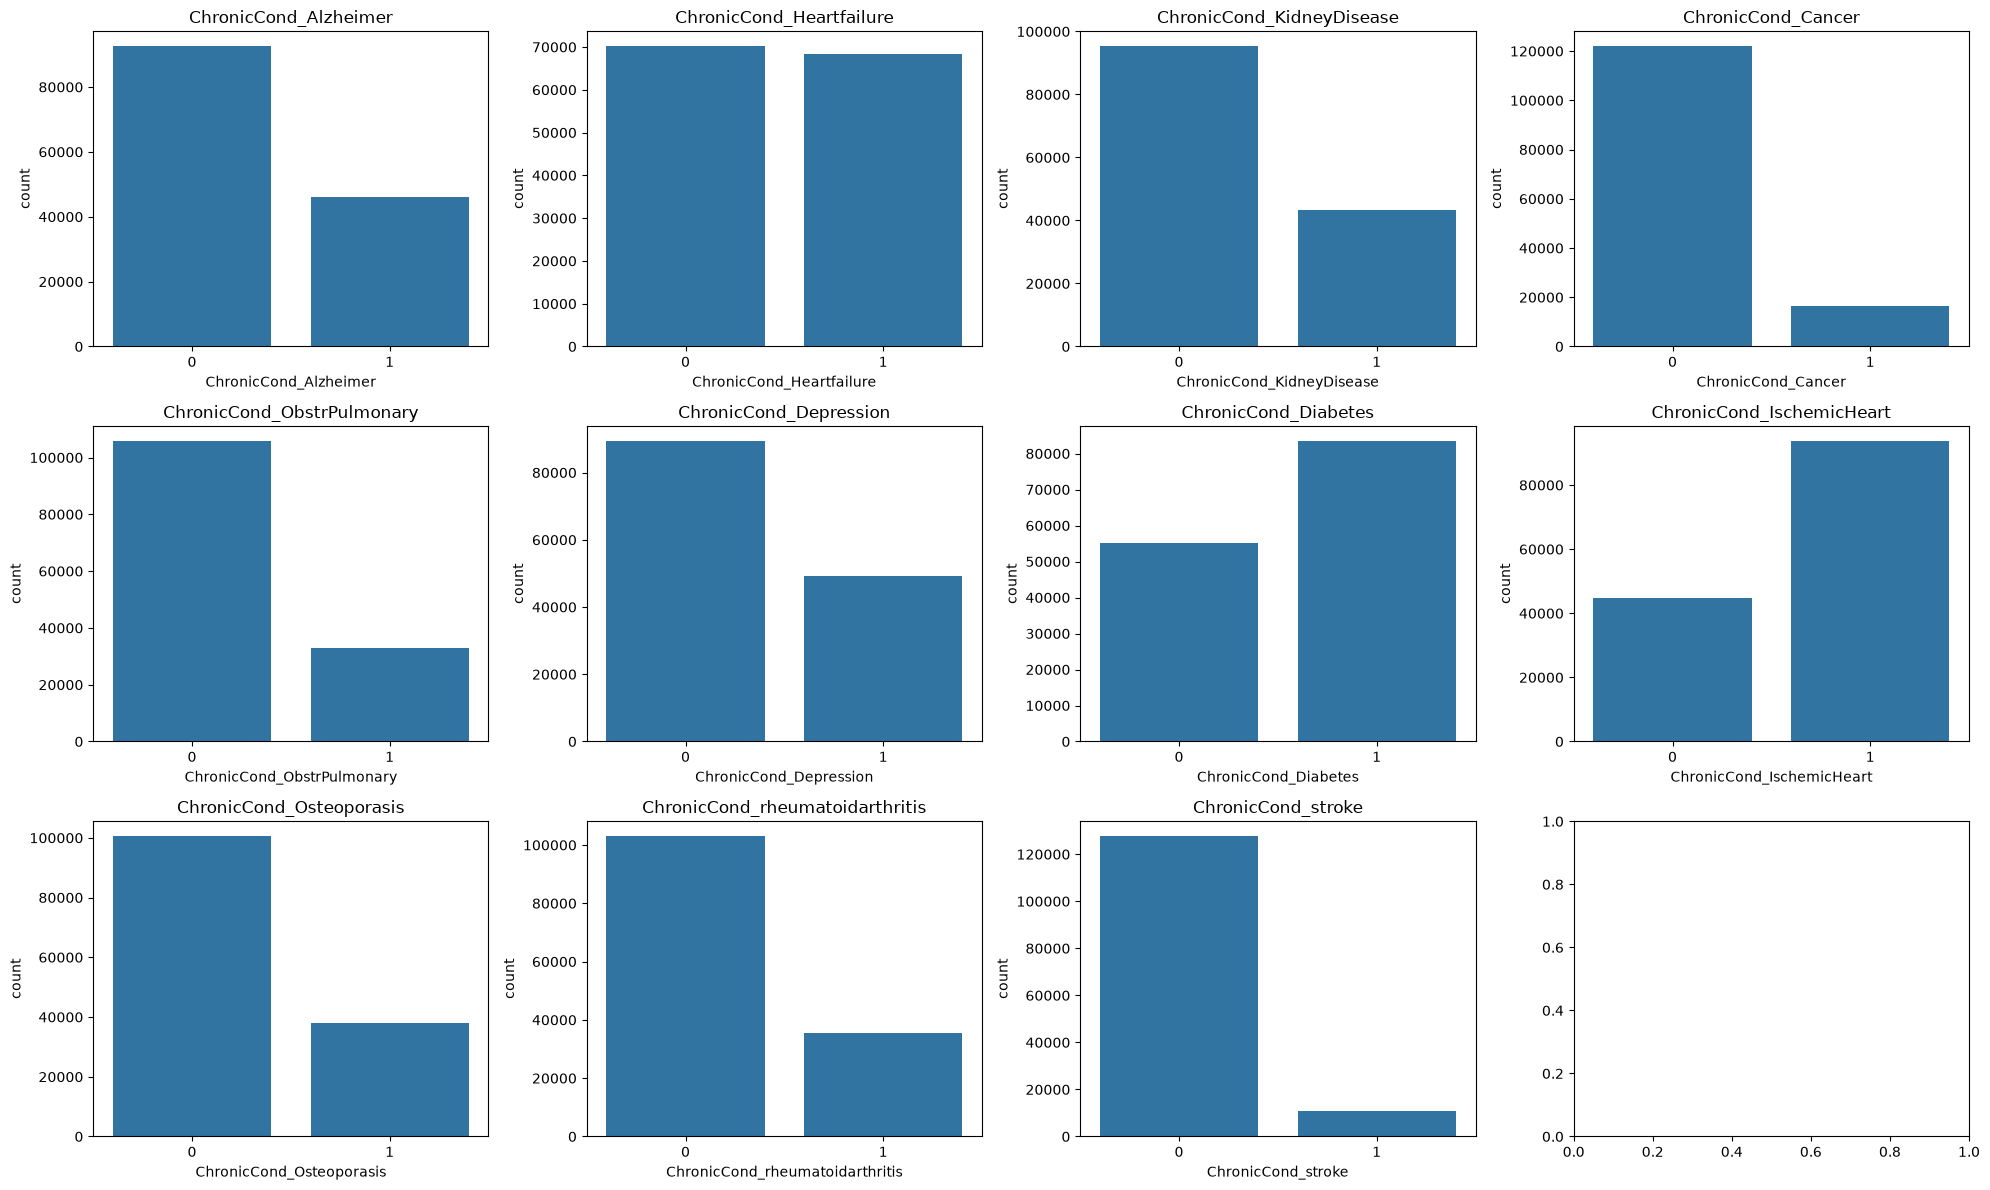

In [206]:
fig, ax =plt.subplots(3,4,figsize=(20,12))
ax =ax.flatten()
for i, col in enumerate(df_diseases):
    sns.countplot(data=Train_Beneficiarydata,x=col, ax=ax[i])
    ax[i].set_title(col)
plt.tight_layout()
plt.show()

Index(['IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt',
       'OPAnnualDeductibleAmt'],
      dtype='str')


<Figure size 2000x10000 with 0 Axes>

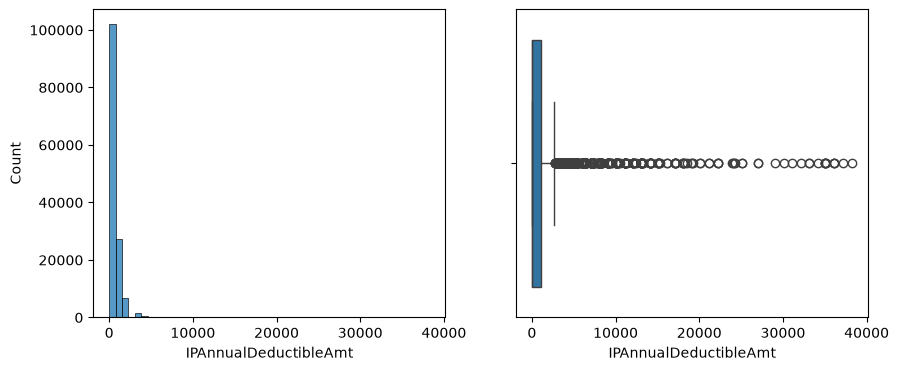

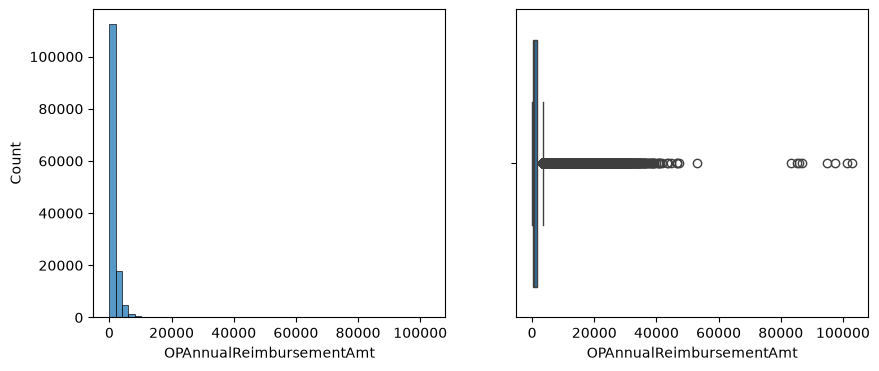

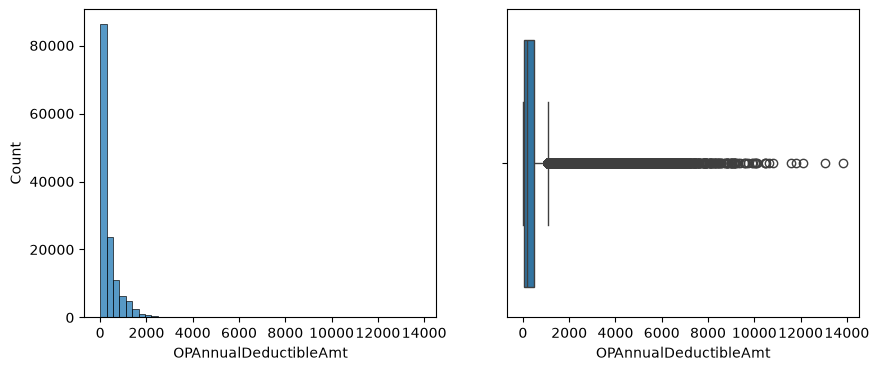

In [207]:
df_numeric =Train_Beneficiarydata.columns[22:]
print(df_numeric)

plt.figure(figsize=(20, 100))
for col in list(df_numeric):
    fig, ax =plt.subplots(1,2,figsize=(10,4))
    sns.histplot(data=Train_Beneficiarydata,x= col,ax=ax[0], bins=50)
    sns.boxplot(data=Train_Beneficiarydata,x=col,ax=ax[1]) 
plt.show()



In [208]:
#0 = alive and 1= DEAD; If x != x,then x must be: NaN orr NaT
Train_Beneficiarydata['Dead_or_Alive'] =Train_Beneficiarydata['DOD'].apply(lambda x: 0 if x != x else 1)
Train_Beneficiarydata['Dead_or_Alive'].value_counts()

Dead_or_Alive
0    137135
1      1421
Name: count, dtype: int64

In [ ]:
#0 = ALIVE and 1=DEAD
Test_Beneficiarydata['Dead_or_Alive'] = Test_Beneficiarydata['DOD'].apply(lambda x: 0 if x != x else 1)
Test_Beneficiarydata['Dead_or_Alive'].value_counts()

Dead_or_Alive
0    63394
1      574
Name: count, dtype: int64

In [210]:
#train data
Train_Beneficiarydata['DOB'] =pd.to_datetime(Train_Beneficiarydata['DOB'], format='%Y-%m-%d')
Train_Beneficiarydata['DOD']= pd.to_datetime(Train_Beneficiarydata['DOD'],format='%Y-%m-%d',errors='coerce')

# use max available date for missing death date
max_date =Train_Beneficiarydata['DOD'].max()
print(max_date)

Train_Beneficiarydata['DOD'] =Train_Beneficiarydata['DOD'].fillna(max_date)
Train_Beneficiarydata['Age']= ((Train_Beneficiarydata['DOD']- Train_Beneficiarydata['DOB']).dt.days/ 365).round()
Train_Beneficiarydata.head(6)

2009-12-01 00:00:00


,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,...,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Dead_or_Alive,Age
0,BENE11001,1943-01-01,2009-12-01,1,1,0,39,230,12,12,...,1,0,1,1,36000,3204,60,70,0,67.0
1,BENE11002,1936-09-01,2009-12-01,0,1,0,39,280,12,12,...,0,0,0,0,0,0,30,50,0,73.0
2,BENE11003,1936-08-01,2009-12-01,1,1,0,52,590,12,12,...,1,0,0,0,0,0,90,40,0,73.0
3,BENE11004,1922-07-01,2009-12-01,1,1,0,39,270,12,12,...,1,1,1,0,0,0,1810,760,0,87.0
4,BENE11005,1935-09-01,2009-12-01,1,1,0,24,680,12,12,...,0,0,0,0,0,0,1790,1200,0,74.0
5,BENE11006,1976-09-01,2009-12-01,0,1,0,23,810,12,12,...,0,0,0,0,0,0,500,0,0,33.0


In [211]:
#do the same for test data
Test_Beneficiarydata['DOB'] =pd.to_datetime(Test_Beneficiarydata['DOB'], format='%Y-%m-%d')
Test_Beneficiarydata['DOD'] =pd.to_datetime(Test_Beneficiarydata['DOD'],format='%Y-%m-%d',errors='coerce')

Test_Beneficiarydata['DOD']= Test_Beneficiarydata['DOD'].fillna(max_date)
Test_Beneficiarydata['Age']= ((Test_Beneficiarydata['DOD'] -Test_Beneficiarydata['DOB']).dt.days/365).round()
Test_Beneficiarydata.head(6)

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,...,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Dead_or_Alive,Age
0,BENE11001,1943-01-01,2009-12-01,1,1,0,39,230,12,12,...,1,0,1,1,36000,3204,60,70,0,67.0
1,BENE11007,1940-09-01,2009-12-01,0,2,0,45,610,12,12,...,0,1,1,0,0,0,1490,160,1,69.0
2,BENE11010,1936-07-01,2009-12-01,1,1,0,41,30,12,12,...,1,1,0,0,0,0,1170,660,0,73.0
3,BENE11011,1914-03-01,2009-12-01,1,2,0,1,360,12,12,...,0,0,1,1,5000,1068,250,320,0,96.0
4,BENE11014,1938-04-01,2009-12-01,1,1,1,45,780,12,12,...,1,0,0,0,21260,2136,120,100,0,72.0
5,BENE11016,1919-09-01,2009-12-01,0,2,0,34,400,12,12,...,1,1,0,1,0,0,2320,1480,0,90.0


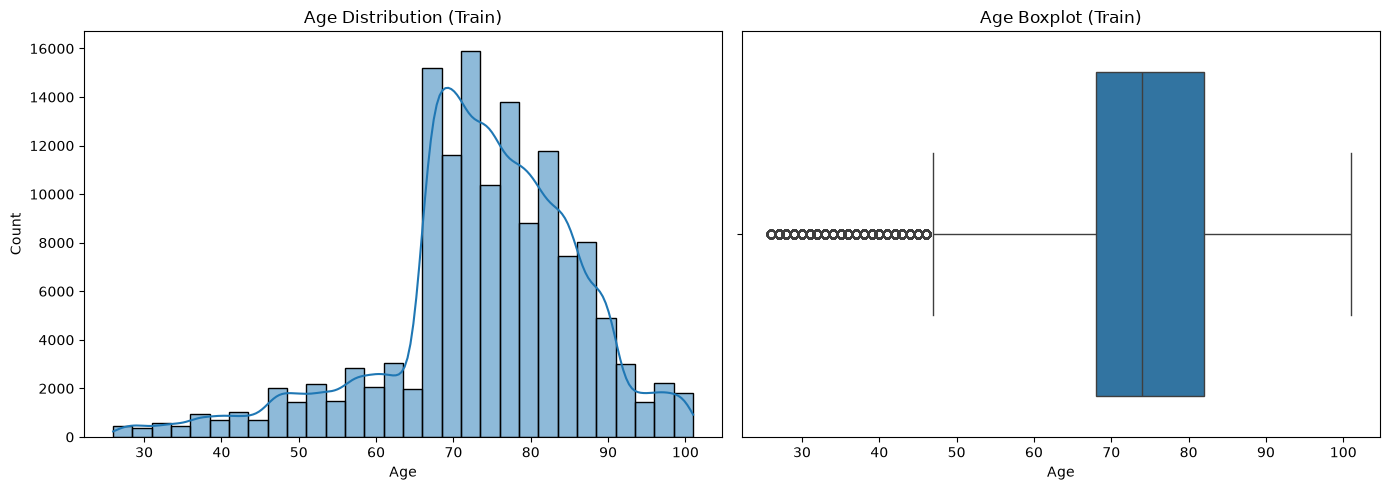

In [212]:
fig, axes =plt.subplots(1,2, figsize=(14,5))

# Histogram
sns.histplot(Train_Beneficiarydata['Age'], bins=30,kde=True,ax=axes[0])
axes[0].set_title("Age Distribution (Train)"), 
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

#boxplot
sns.boxplot(x = Train_Beneficiarydata['Age'],ax=axes[1])
axes[1].set_title("Age Boxplot (Train)")
axes[1].set_xlabel("Age")






plt.tight_layout()
plt.show()

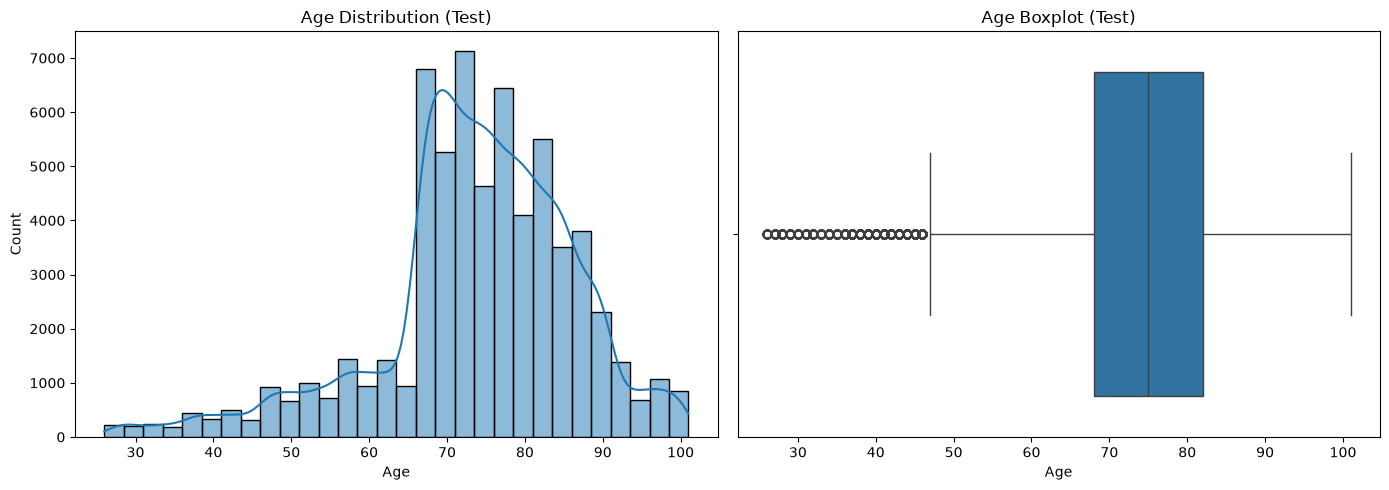

In [213]:
fig, axes =plt.subplots(1,2,figsize=(14,5))
#histogram
sns.histplot(Test_Beneficiarydata['Age'], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Age Distribution (Test)"), 
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

#Boxplot
sns.boxplot(x = Test_Beneficiarydata['Age'],ax=axes[1])
axes[1].set_title("Age Boxplot (Test)")
axes[1].set_xlabel("Age")





plt.tight_layout()
plt.show()

In [214]:
Train_Inpatientdata.head(5)

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,...,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,...,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,...,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN


In [215]:
Test_Inpatientdata.isna().sum()

BeneID                       0
ClaimID                      0
ClaimStartDt                 0
ClaimEndDt                   0
Provider                     0
InscClaimAmtReimbursed       0
AttendingPhysician          31
OperatingPhysician        3962
OtherPhysician            8538
AdmissionDt                  0
ClmAdmitDiagnosisCode        0
DeductibleAmtPaid          196
DischargeDt                  0
DiagnosisGroupCode           0
ClmDiagnosisCode_1           0
ClmDiagnosisCode_2          54
ClmDiagnosisCode_3         169
ClmDiagnosisCode_4         404
ClmDiagnosisCode_5         719
ClmDiagnosisCode_6        1197
ClmDiagnosisCode_7        1736
ClmDiagnosisCode_8        2360
ClmDiagnosisCode_9        3238
ClmDiagnosisCode_10       8664
ClmProcedureCode_1        4118
ClmProcedureCode_2        8297
ClmProcedureCode_3        9328
ClmProcedureCode_4        9522
ClmProcedureCode_5        9549
ClmProcedureCode_6        9551
dtype: int64

In [216]:
Train_Inpatientdata.columns

Index(['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician',
       'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode',
       'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode',
       'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3',
       'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6',
       'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9',
       'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2',
       'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5',
       'ClmProcedureCode_6'],
      dtype='str')

In [217]:
Train_Outpatientdata.columns

Index(['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician',
       'OtherPhysician', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2',
       'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5',
       'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8',
       'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10', 'ClmProcedureCode_1',
       'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4',
       'ClmProcedureCode_5', 'ClmProcedureCode_6', 'DeductibleAmtPaid',
       'ClmAdmitDiagnosisCode'],
      dtype='str')

In [218]:
Train_Outpatientdata['Provider']

0         PRV56011
1         PRV57610
2         PRV57595
3         PRV56011
4         PRV56011
            ...   
517732    PRV53699
517733    PRV53702
517734    PRV53676
517735    PRV53689
517736    PRV53689
Name: Provider, Length: 517737, dtype: str

In [219]:
#finding columns unique to each dataset
diff_columes_1=[col for col in Train_Inpatientdata.columns if col not in Train_Outpatientdata.columns]
diff_columes_2=[col for col in Train_Outpatientdata.columns if col not in Train_Inpatientdata.columns]
print(diff_columes_1, ";",diff_columes_2)        #all outpatient columns are also present in the inpatient dataset.

['AdmissionDt', 'DischargeDt', 'DiagnosisGroupCode'] ; []


In [220]:
#calculate length of hospital stay for inpatient admissions.
for df in [Train_Inpatientdata, Test_Inpatientdata]:
    df['AdmissionDt'] =pd.to_datetime(df['AdmissionDt'])
    df['DischargeDt'] =pd.to_datetime(df['DischargeDt'])

    df['InHospitalDays'] =((df['DischargeDt']-df['AdmissionDt']).dt.days + 1)
Train_Inpatientdata.head(4)

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,InHospitalDays
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,...,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN,3
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,...,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN,9


#Merge of datasets

In [221]:
#combine both inpatient and outpatient patient claims
Train_Both_Patients =pd.merge(Train_Outpatientdata,Train_Inpatientdata,on = Train_Outpatientdata.columns.tolist(),how = 'outer')
Test_Both_Patients =pd.merge(Test_Outpatientdata,Test_Inpatientdata,on = Test_Outpatientdata.columns.tolist(),how = 'outer')
Train_Both_Patients.shape, Test_Both_Patients.shape

((558211, 31), (135392, 31))

In [222]:
#merge beneficiary details with patient claims data
Train_All_Patientdata = pd.merge(Train_Both_Patients,Train_Beneficiarydata, on='BeneID', how='inner')
Test_All_Patientdata = pd.merge(Test_Both_Patients,Test_Beneficiarydata,on='BeneID',how='inner')
Train_All_Patientdata.shape, Test_All_Patientdata.shape

((558211, 57), (135392, 57))

In [223]:
Train["PotentialFraud"].value_counts()

PotentialFraud
No     4904
Yes     506
Name: count, dtype: int64

In [224]:
Train.shape, Test.shape

((5410, 2), (1353, 1))

In [225]:
#merge all the patient claims data with provider fraud labels
Train_Label_AllPatientdata =pd.merge(Train_All_Patientdata, Train,on='Provider')
Test_noLabel_AllPatientdata =pd.merge(Test_All_Patientdata,Test,on = 'Provider')
Train_Label_AllPatientdata.shape,Test_noLabel_AllPatientdata.shape

((558211, 58), (135392, 57))

In [226]:
Train_Label_AllPatientdata.head(5)

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,...,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Dead_or_Alive,Age,PotentialFraud
0,BENE100000,CLM126832,2009-01-08,2009-01-08,PRV57172,50,PHY383401,NaN,NaN,79678,...,0,0,0,0,0,120,30,0,72.0,Yes
1,BENE100000,CLM351838,2009-05-10,2009-05-10,PRV57172,70,PHY370909,NaN,PHY363377,71656,...,0,0,0,0,0,120,30,0,72.0,Yes
2,BENE100001,CLM229075,2009-03-05,2009-03-05,PRV55158,70,PHY383478,NaN,NaN,64881,...,1,0,1,0,0,2530,540,0,70.0,No
3,BENE100001,CLM258631,2009-03-21,2009-03-21,PRV54966,70,PHY347511,NaN,NaN,36401,...,1,0,1,0,0,2530,540,0,70.0,Yes
4,BENE100001,CLM332544,2009-04-30,2009-05-02,PRV54890,90,PHY343317,PHY408367,PHY408367,2948,...,1,0,1,0,0,2530,540,0,70.0,No


In [227]:
Test_noLabel_AllPatientdata.head(5)

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,...,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Dead_or_Alive,Age
0,BENE100001,CLM129501,2009-01-10,2009-01-10,PRV52050,1100,PHY364771,NaN,NaN,V074,...,1,1,0,1,0,0,2530,540,0,70.0
1,BENE100002,CLM623189,2009-10-10,2009-10-10,PRV52083,60,PHY402651,NaN,PHY315572,V5867,...,1,0,0,1,12250,1068,1760,660,0,71.0
2,BENE100004,CLM546697,2009-08-26,2009-09-15,PRV53275,1500,PHY364921,NaN,PHY364921,V5631,...,1,1,0,0,14270,2136,1880,700,0,67.0
3,BENE100004,CLM63603,2009-08-12,2009-08-17,PRV52959,11000,PHY410241,NaN,NaN,69514,...,1,1,0,0,14270,2136,1880,700,0,67.0
4,BENE100010,CLM299397,2009-04-12,2009-04-12,PRV52050,60,PHY342001,NaN,PHY359807,V704,...,1,0,1,0,13400,2136,1050,760,0,82.0


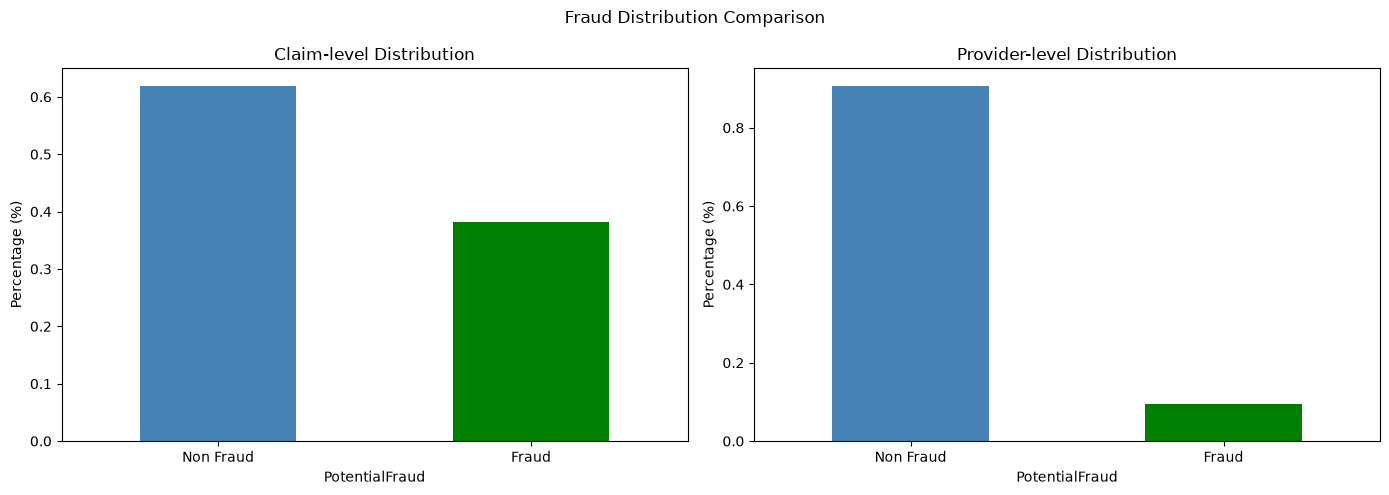

In [228]:
fig, axes=plt.subplots(1, 2, figsize=(14, 5))

#claim-level
claim_dist=(Train_Label_AllPatientdata['PotentialFraud'].value_counts(normalize=True))
claim_dist.plot(kind='bar',ax=axes[0],color=['steelblue', 'green'])

axes[0].set_title('Claim-level Distribution')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xticklabels(['Non Fraud','Fraud'], rotation=0)

#provider-level
provider_dist=(Train['PotentialFraud'].value_counts(normalize=True))
provider_dist.plot(kind='bar',ax=axes[1], color=['steelblue', 'green'])

axes[1].set_title('Provider-level Distribution')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(['Non Fraud','Fraud'],rotation=0)

plt.suptitle('Fraud Distribution Comparison')
plt.tight_layout()
plt.show()


#fraudulent providers generate disproportionately more claims than non-fraudulent providers. (looking at graph above)

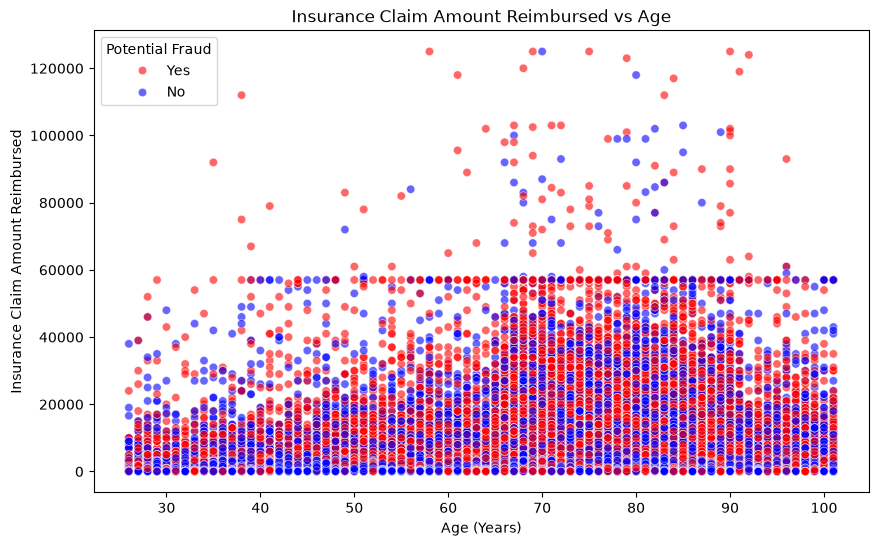

In [229]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=Train_Label_AllPatientdata,
    x='Age',
    y='InscClaimAmtReimbursed',
    hue='PotentialFraud',
    palette={'Yes':'red','No':'blue'},
    alpha=0.6
)

plt.title('Insurance Claim Amount Reimbursed vs Age')
plt.xlabel('Age (Years)')
plt.ylabel('Insurance Claim Amount Reimbursed')

plt.legend(title='Potential Fraud')
plt.show()

In [230]:
train_df=Train_Label_AllPatientdata.copy()
test_df=Test_noLabel_AllPatientdata.copy()

train_df['Dataset'] ='train'
test_df['Dataset']='test'

# Add missing target column to test
test_df['PotentialFraud'] =np.nan

all_data =pd.concat([train_df, test_df], axis=0,ignore_index=True,sort=False)

print(all_data.shape)

(693603, 59)


In [231]:
all_data.head(3)

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,...,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Dead_or_Alive,Age,PotentialFraud,Dataset
0,BENE100000,CLM126832,2009-01-08,2009-01-08,PRV57172,50,PHY383401,NaN,NaN,79678,...,0,0,0,0,120,30,0,72.0,Yes,train
1,BENE100000,CLM351838,2009-05-10,2009-05-10,PRV57172,70,PHY370909,NaN,PHY363377,71656,...,0,0,0,0,120,30,0,72.0,Yes,train
2,BENE100001,CLM229075,2009-03-05,2009-03-05,PRV55158,70,PHY383478,NaN,NaN,64881,...,0,1,0,0,2530,540,0,70.0,No,train


In [232]:
all_data.isna().sum()

BeneID                                  0
ClaimID                                 0
ClaimStartDt                            0
ClaimEndDt                              0
Provider                                0
InscClaimAmtReimbursed                  0
AttendingPhysician                   1855
OperatingPhysician                 551963
OtherPhysician                     445235
ClmDiagnosisCode_1                  13031
ClmDiagnosisCode_2                 243391
ClmDiagnosisCode_3                 391900
ClmDiagnosisCode_4                 489450
ClmDiagnosisCode_5                 554881
ClmDiagnosisCode_6                 589051
ClmDiagnosisCode_7                 611641
ClmDiagnosisCode_8                 627437
ClmDiagnosisCode_9                 641912
ClmDiagnosisCode_10                687443
ClmProcedureCode_1                 664826
ClmProcedureCode_2                 686850
ClmProcedureCode_3                 692409
ClmProcedureCode_4                 693456
ClmProcedureCode_5                

In [233]:
all_data["Dataset"].value_counts()

Dataset
train    558211
test     135392
Name: count, dtype: int64

In [234]:
print(all_data['PotentialFraud'].isna().sum())

135392


In [235]:
print(all_data.columns.tolist())

['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6', 'DeductibleAmtPaid', 'ClmAdmitDiagnosisCode', 'AdmissionDt', 'DischargeDt', 'DiagnosisGroupCode', 'InHospitalDays', 'DOB', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator', 'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov', 'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease', 'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression', 'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart', 'ChronicCond_Osteoporasis', 'ChronicCond_rhe

In [236]:
all_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 693603 entries, 0 to 693602
Data columns (total 59 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   BeneID                           693603 non-null  str           
 1   ClaimID                          693603 non-null  str           
 2   ClaimStartDt                     693603 non-null  str           
 3   ClaimEndDt                       693603 non-null  str           
 4   Provider                         693603 non-null  str           
 5   InscClaimAmtReimbursed           693603 non-null  int64         
 6   AttendingPhysician               691748 non-null  str           
 7   OperatingPhysician               141640 non-null  str           
 8   OtherPhysician                   248368 non-null  str           
 9   ClmDiagnosisCode_1               680572 non-null  str           
 10  ClmDiagnosisCode_2               450212 non-null  str  

#Clean and prepare claim level data

tldr:replaces the previous unfinished code and keeps the workflow focused on EDA and provider-level feature creation

1. Clean claim-level values.
2. Create claim-level indicators
3. Aggregate claims to the provider level
4. Compare fraudulent and non-fraudulent providers
5. Export model ready train and test tables

In [254]:
#work on a copy so the earlier merged dataset remains unchanged
claims=all_data.copy()

numeric_columns =[
    "InscClaimAmtReimbursed",
    "DeductibleAmtPaid",
    "InHospitalDays",
    "Age",
    "IPAnnualReimbursementAmt",
    "IPAnnualDeductibleAmt",
    "OPAnnualReimbursementAmt",
    "OPAnnualDeductibleAmt",
]

for column in numeric_columns:
    if column in claims.columns:
        claims[column] =pd.to_numeric(
            claims[column],
            errors="coerce",
        ).fillna(0)

for column in ["ClaimStartDt", "ClaimEndDt", "AdmissionDt", "DischargeDt"]:
    if column in claims.columns:
        claims[column]=pd.to_datetime(
            claims[column],
            errors="coerce",
        )

print("Prepared claim-level shape:", claims.shape)

Prepared claim-level shape: (693603, 59)


#Create claim-level indicators

these variables summarize claim complexity, utilization, and billing behavior before provider-level aggregation

In [238]:
claims["ClaimDurationDays"]=(
    claims["ClaimEndDt"] -claims["ClaimStartDt"]
).dt.days.add(1).clip(lower=1).fillna(1)

claims["IsInpatient"] =claims["AdmissionDt"].notna().astype(int)

diagnosis_columns =[
    column for column in claims.columns
    if column.startswith("ClmDiagnosisCode_")
]

procedure_columns =[
    column for column in claims.columns
    if column.startswith("ClmProcedureCode_")
]

physician_columns=[
    column for column in[
        "AttendingPhysician",
        "OperatingPhysician",
        "OtherPhysician",
]
    if column in claims.columns
]

claims["DiagnosisCount"]=claims[diagnosis_columns].notna().sum(axis=1)
claims["ProcedureCount"] = claims[procedure_columns].notna().sum(axis=1)
claims["PhysicianCount"] =claims[physician_columns].notna().sum(axis=1)

chronic_columns=[
    column for column in claims.columns
    if column.startswith("ChronicCond_")
]

claims["ChronicConditionCount"] =claims[chronic_columns].sum(axis=1)

claims["AnnualReimbursementTotal"]=(
    claims["IPAnnualReimbursementAmt"]
    +claims["OPAnnualReimbursementAmt"]
)

claims["AnnualDeductibleTotal"] = (
    claims["IPAnnualDeductibleAmt"]
    +claims["OPAnnualDeductibleAmt"]
)

claims[
[
        "ClaimDurationDays",
        "IsInpatient",
        "DiagnosisCount",
        "ProcedureCount",
        "PhysicianCount",
        "ChronicConditionCount",
]
].describe().T

,count,mean,std,min,25%,50%,75%,max
ClaimDurationDays,693603.0,2.726439,4.905386,1.0,1.0,1.0,1.0,37.0
IsInpatient,693603.0,0.072123,0.258692,0.0,0.0,0.0,0.0,1.0
DiagnosisCount,693603.0,3.007330,2.445533,0.0,1.0,2.0,4.0,10.0
ProcedureCount,693603.0,0.053175,0.279470,0.0,0.0,0.0,0.0,5.0
PhysicianCount,693603.0,1.559618,0.639362,0.0,1.0,1.0,2.0,3.0
ChronicConditionCount,693603.0,4.501150,2.333040,0.0,3.0,5.0,6.0,11.0


#features for the provider level

fraud labels are assigned at the provider level. As a result, claim records are aggregated into one row per provider.

In [239]:
def build_provider_features(data):
    provider = data.groupby("Provider").agg(
        ClaimCount=("ClaimID", "count"),
        UniqueBeneficiaries=("BeneID", "nunique"),

        ReimbursementTotal=("InscClaimAmtReimbursed","sum"),
        ReimbursementMean=("InscClaimAmtReimbursed","mean"),
        ReimbursementMedian=("InscClaimAmtReimbursed", "median"),
        ReimbursementStd=("InscClaimAmtReimbursed", "std"),
        ReimbursementMax=("InscClaimAmtReimbursed", "max"),

        DeductibleTotal=("DeductibleAmtPaid","sum"),
        DeductibleMean=("DeductibleAmtPaid","mean"),
        DeductibleMax=("DeductibleAmtPaid", "max"),

        InpatientClaimCount=("IsInpatient", "sum"),
        InpatientClaimRatio=("IsInpatient", "mean"),

        ClaimDurationMean=("ClaimDurationDays", "mean"),
        HospitalStayMean=("InHospitalDays", "mean"),
        HospitalStayMax=("InHospitalDays", "max"),

        DiagnosisCountMean=("DiagnosisCount","mean"),
        ProcedureCountMean=("ProcedureCount","mean"),
        PhysicianCountMean=("PhysicianCount", "mean"),

        BeneficiaryAgeMean=("Age","mean"),
        BeneficiaryAgeStd=("Age", "std"),
        ChronicConditionMean=("ChronicConditionCount","mean"),

        AnnualReimbursementMean=("AnnualReimbursementTotal", "mean"),
        AnnualDeductibleMean=("AnnualDeductibleTotal", "mean"),

        UniqueAttendingPhysicians=("AttendingPhysician","nunique"),
        UniquePrimaryDiagnoses=("ClmDiagnosisCode_1", "nunique"),
        UniquePrimaryProcedures=("ClmProcedureCode_1","nunique"),
    ).reset_index()

    provider["ClaimsPerBeneficiary"]=(
        provider["ClaimCount"]
        / provider["UniqueBeneficiaries"].replace(0,np.nan)
    )

    provider["ReimbursementPerBeneficiary"]=(
        provider["ReimbursementTotal"]
        / provider["UniqueBeneficiaries"].replace(0,np.nan)
    )

    provider["ReimbursementPerClaim"]=(
        provider["ReimbursementTotal"]
        / provider["ClaimCount"].replace(0, np.nan)
    )

    provider["DeductibleToReimbursementRatio"]=(
        provider["DeductibleTotal"]
        / provider["ReimbursementTotal"].replace(0,np.nan)
    )

    provider["PhysicianDiversityRatio"]=(
        provider["UniqueAttendingPhysicians"]
        / provider["ClaimCount"].replace(0,np.nan)
    )

    provider["DiagnosisDiversityRatio"]=(
        provider["UniquePrimaryDiagnoses"]
        / provider["ClaimCount"].replace(0, np.nan)
    )

    provider["ProcedureDiversityRatio"] = (
        provider["UniquePrimaryProcedures"]
        / provider["ClaimCount"].replace(0,np.nan)
    )

    return(
        provider
        .replace([np.inf,-np.inf],np.nan)
        .fillna(0)
    )


provider_features=build_provider_features(claims)

print("Provider-level shape:",provider_features.shape)
provider_features.head()

Provider-level shape: (6763, 34)


,Provider,ClaimCount,UniqueBeneficiaries,ReimbursementTotal,ReimbursementMean,ReimbursementMedian,ReimbursementStd,ReimbursementMax,DeductibleTotal,DeductibleMean,...,UniqueAttendingPhysicians,UniquePrimaryDiagnoses,UniquePrimaryProcedures,ClaimsPerBeneficiary,ReimbursementPerBeneficiary,ReimbursementPerClaim,DeductibleToReimbursementRatio,PhysicianDiversityRatio,DiagnosisDiversityRatio,ProcedureDiversityRatio
0,PRV51001,25,24,104640,4185.600000,400.0,10796.091144,42000,5340.0,213.600000,...,14,23,2,1.041667,4360.000000,4185.600000,0.051032,0.560000,0.920000,0.080000
1,PRV51002,205,169,53790,262.390244,80.0,609.021752,6010,380.0,1.853659,...,76,174,0,1.213018,318.284024,262.390244,0.007065,0.370732,0.848780,0.000000
2,PRV51003,132,117,605670,4588.409091,1750.0,7309.794729,57000,66286.0,502.166667,...,44,115,32,1.128205,5176.666667,4588.409091,0.109442,0.333333,0.871212,0.242424
3,PRV51004,149,138,52170,350.134228,70.0,689.963754,3300,310.0,2.080537,...,38,128,0,1.079710,378.043478,350.134228,0.005942,0.255034,0.859060,0.000000
4,PRV51005,1165,495,280910,241.124464,70.0,491.556392,4080,3700.0,3.175966,...,6,809,0,2.353535,567.494949,241.124464,0.013171,0.005150,0.694421,0.000000


#create train and test provider datasets

The training and test provider sets do not overlap, so they can be separated safely after aggregation.

In [240]:
train_provider = (
    Train[["Provider", "PotentialFraud"]]
    .merge(provider_features,on="Provider", how="left")
)

test_provider = (
    Test[["Provider"]]
    .merge(provider_features,on="Provider", how="left")
)

feature_columns = [
    column for column in train_provider.columns
    if column not in ["Provider","PotentialFraud"]
]

train_provider[feature_columns] =(
    train_provider[feature_columns].fillna(0)
)

test_provider[feature_columns]= (
    test_provider[feature_columns].fillna(0)
)

train_provider["FraudLabel"]= (
    train_provider["PotentialFraud"]
    .map({"No": 0, "Yes": 1})
)

print("Train provider data:", train_provider.shape)
print("Test provider data:",test_provider.shape)
print()
print(train_provider["PotentialFraud"].value_counts())

Train provider data: (5410, 36)
Test provider data: (1353, 34)

PotentialFraud
No     4904
Yes     506
Name: count, dtype: int64


#Compare fraudulent and non-fraudulent providers
The table below compares median provider values because many reimbursement and utilization features are strongly skewed

In [241]:
comparison_features=[
    "ClaimCount",
    "UniqueBeneficiaries",
    "ReimbursementTotal",
    "ReimbursementPerClaim",
    "ClaimsPerBeneficiary",
    "InpatientClaimRatio",
    "DiagnosisCountMean",
    "ProcedureCountMean",
    "ChronicConditionMean",
]

fraud_comparison =(
    train_provider
    .groupby("PotentialFraud")[comparison_features]
    .median()
    .T
    .rename(
        columns={
            "No": "NonFraud_Median",
            "Yes": "Fraud_Median",
        }
    )
)

fraud_comparison["Fraud_to_NonFraud_Ratio"]=(
    fraud_comparison["Fraud_Median"]
    / fraud_comparison["NonFraud_Median"].replace(0, np.nan)
)

fraud_comparison.sort_values(
    "Fraud_to_NonFraud_Ratio",
    ascending=False,
)

PotentialFraud,NonFraud_Median,Fraud_Median,Fraud_to_NonFraud_Ratio
ReimbursementTotal,15055.000000,373450.000000,24.805712
ReimbursementPerClaim,332.192088,2576.480084,7.755995
ClaimCount,27.000000,155.500000,5.759259
UniqueBeneficiaries,22.000000,117.000000,5.318182
DiagnosisCountMean,2.763763,3.779757,1.367613
ClaimsPerBeneficiary,1.083333,1.192113,1.100412
ChronicConditionMean,4.500000,4.716257,1.048057
InpatientClaimRatio,0.000000,0.217677,NaN
ProcedureCountMean,0.000000,0.174166,NaN


#visualizing trends for the provider level

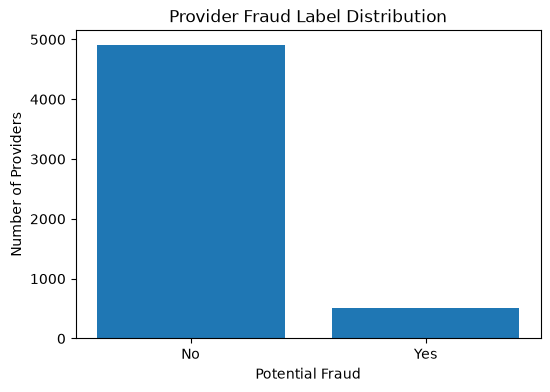

In [242]:
label_counts=train_provider["PotentialFraud"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(label_counts.index, label_counts.values)
plt.title("Provider Fraud Label Distribution")
plt.xlabel("Potential Fraud")
plt.ylabel("Number of Providers")
plt.show()

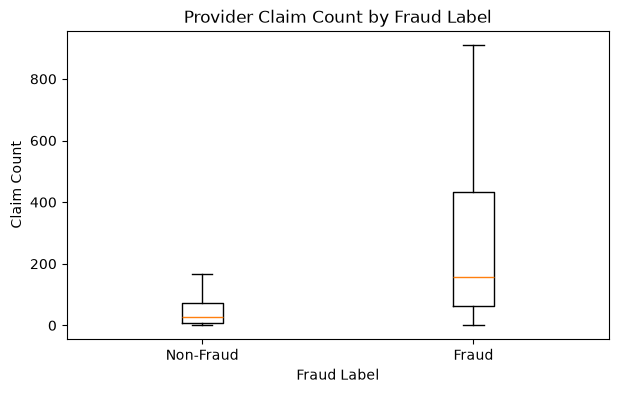

In [243]:
claim_count_groups=[
    train_provider.loc[
        train_provider["PotentialFraud"]==label,
        "ClaimCount",
    ].dropna()
    for label in ["No","Yes"]
]

plt.figure(figsize=(7,4))

plt.boxplot(
    claim_count_groups,
    tick_labels=["Non-Fraud","Fraud"],
    showfliers=False,
)



plt.title("Provider Claim Count by Fraud Label")
plt.xlabel("Fraud Label")
plt.ylabel("Claim Count")
plt.show()

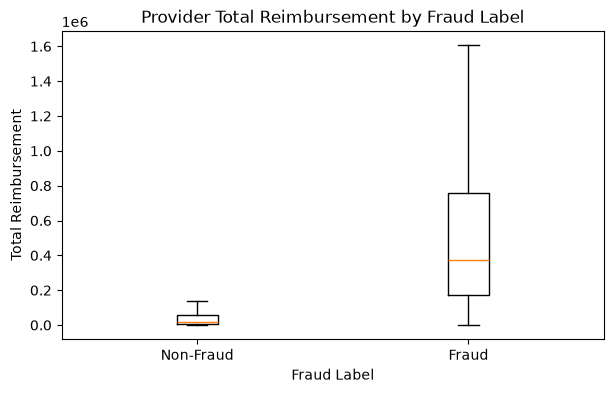

In [244]:
reimbursement_groups=[
    train_provider.loc[
        train_provider["PotentialFraud"] ==label,
        "ReimbursementTotal",
    ].dropna()
    for label in ["No","Yes"]
]

plt.figure(figsize=(7, 4))

plt.boxplot(
    reimbursement_groups,
    tick_labels=["Non-Fraud","Fraud"],
    showfliers=False,
)

plt.title("Provider Total Reimbursement by Fraud Label")
plt.xlabel("Fraud Label")
plt.ylabel("Total Reimbursement")
plt.show()

#using numbers to represent association with fraud
Correlation is used here only as an exploratory screening measure.

In [245]:
numeric_features=train_provider.select_dtypes(include=np.number)

fraud_correlations=(
    numeric_features
    .corr()["FraudLabel"]
    .drop("FraudLabel")
    .sort_values(key=abs,ascending=False)
)

fraud_correlations.head(15).to_frame(
    "CorrelationWithFraud"
)

,CorrelationWithFraud
ReimbursementTotal,0.575558
UniquePrimaryProcedures,0.564768
HospitalStayMax,0.542662
DeductibleTotal,0.532070
InpatientClaimCount,0.525393
ReimbursementMax,0.514671
UniquePrimaryDiagnoses,0.400036
UniqueBeneficiaries,0.393531
ClaimCount,0.374197
DiagnosisDiversityRatio,-0.367946


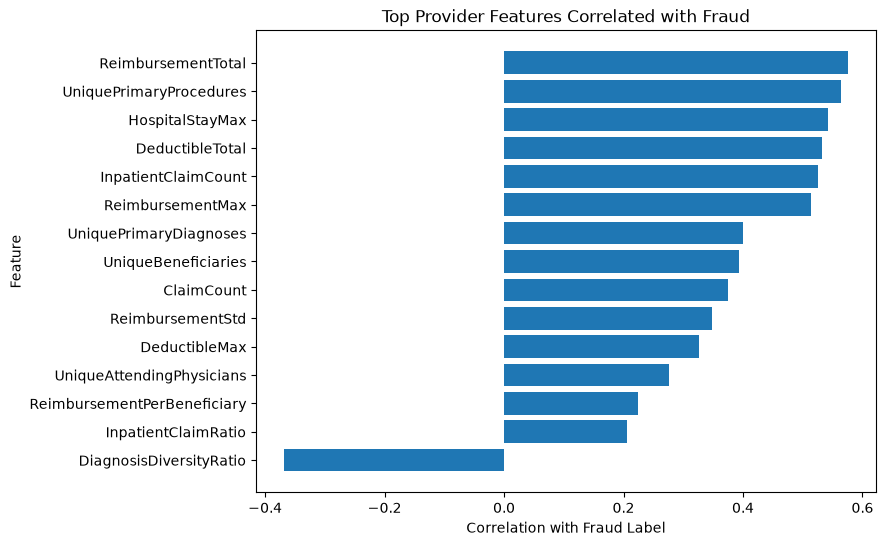

In [246]:
top_correlations=(
    fraud_correlations
    .head(15)
    .sort_values()
)

plt.figure(figsize=(8,6))
plt.barh(
    top_correlations.index,
    top_correlations.values,
)
plt.title("Top Provider Features Correlated with Fraud")
plt.xlabel("Correlation with Fraud Label")
plt.ylabel("Feature")
plt.show()

#checking the quality of data

In [247]:
quality_summary=pd.DataFrame({
    "TrainMissing": train_provider.isna().sum(),
    "TestMissing": test_provider.isna().sum(),
    "TrainUnique": train_provider.nunique(),
}).sort_values(
    "TrainMissing",
    ascending=False,
)

print(
    "Duplicate train providers:",
    train_provider["Provider"].duplicated().sum(),
)

print(
    "Duplicate test providers:",
    test_provider["Provider"].duplicated().sum(),
)

print(
    "Infinite train values:",
    np.isinf(
        train_provider.select_dtypes(include=np.number)
    ).sum().sum(),
)

quality_summary.head(15)

Duplicate train providers: 0
Duplicate test providers: 0
Infinite train values: 0


,TrainMissing,TestMissing,TrainUnique
AnnualDeductibleMean,0,0.0,5135
AnnualReimbursementMean,0,0.0,5283
PhysicianDiversityRatio,0,0.0,1920
PotentialFraud,0,NaN,2
ProcedureCountMean,0,0.0,1056
ProcedureDiversityRatio,0,0.0,981
Provider,0,0.0,5410
ReimbursementMax,0,0.0,272
ReimbursementMean,0,0.0,4502
ReimbursementMedian,0,0.0,178


preparing model-ready feature matrices

In [248]:
X = train_provider.drop(
    columns=[
        "Provider",
        "PotentialFraud",
        "FraudLabel",
    ]
)

y=train_provider["FraudLabel"]

X_test=test_provider.drop(
    columns=["Provider"]
)

X_test =X_test.reindex(
    columns=X.columns,
    fill_value=0,
)

print("X shape:",X.shape)
print("y shape:",y.shape)
print("X_test shape:",X_test.shape)
print("Aligned columns:",X.columns.equals(X_test.columns))

X shape: (5410, 33)
y shape: (5410,)
X_test shape: (1353, 33)
Aligned columns: True


saving provider level EDA outputs

In [249]:
from pathlib import Path

OUTPUT_DIR =Path("eda_outputs")
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

train_output =OUTPUT_DIR / "train_provider_features.csv"
test_output= OUTPUT_DIR /"test_provider_features.csv"
comparison_output =OUTPUT_DIR/ "fraud_feature_comparison.csv"
correlation_output =OUTPUT_DIR/ "fraud_feature_correlations.csv"

train_provider.to_csv(
    train_output,
    index=False,
)

test_provider.to_csv(
    test_output,
    index=False,
)

fraud_comparison.to_csv(
    comparison_output,
)

fraud_correlations.to_csv(
    correlation_output,
    header=["CorrelationWithFraud"],
)

print("Saved:")
print("-",train_output.resolve())
print("-",test_output.resolve())
print("-", comparison_output.resolve())
print("-", correlation_output.resolve())

Saved:
- /Users/guo/Desktop/Chandler Healthcare LLMs Project/healthcare fraud detection V3/notebooks/eda_outputs/train_provider_features.csv
- /Users/guo/Desktop/Chandler Healthcare LLMs Project/healthcare fraud detection V3/notebooks/eda_outputs/test_provider_features.csv
- /Users/guo/Desktop/Chandler Healthcare LLMs Project/healthcare fraud detection V3/notebooks/eda_outputs/fraud_feature_comparison.csv
- /Users/guo/Desktop/Chandler Healthcare LLMs Project/healthcare fraud detection V3/notebooks/eda_outputs/fraud_feature_correlations.csv


conclusion

Through the provider-level analysis, it highlights patterns that may be useful for fraud screening:

- unusually high claim volume
- high reimbursement totals
- repeated claims per beneficiary
- unusual inpatient utilization
- diagnosis and procedure concentration
- concentrated physician-provider relationships

These patterns are screening indicators only. They should be combined with model validation and domain review before making fraud determinations.